# Base Unet Training Exp for CHASEDB1 dataset (w + wo augs)

In [1]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  # looks for a "src" sibling/parent of the notebook


[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


In [5]:
import os, json, time, math, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- data utils ---
from src.data.prepare_dataset import (
    build_pairs_for_split,
    build_all_train_pairs,
    assert_dataset_layout,
    sanity_check_sample_alignment,
)
from src.data.dataloader import make_loaders
from src.data.augmentations import get_train_augs, get_val_augs

from src.models.unet import UNet

# --- evaluation & visualization ---
from src.evaluation.evaluate import evaluate_and_print
from src.evaluation.visualization import visualize_samples

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_DIR = Path("./runs/base_unet_checkpoints/chasedb1")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
SEED = 1337
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.benchmark = True


In [6]:
data_dir = "../data/raw/STARE"

train_pairs = build_pairs_for_split(dataset_root=data_dir, split="training", label_folder="1st_manual")
test_pairs  = build_pairs_for_split(dataset_root=data_dir, split="test",     label_folder="1st_manual")

train_loader, test_loader = make_loaders(
    train_pairs=train_pairs,
    val_pairs=test_pairs,      
    image_size=512,
    batch_size=2,
    num_workers=4,       
    seed=1337,
    strict_fov=True,
    augs_train= None,
    augs_val = None
    #augs_train=get_train_augs(512),   # real augmentations
    #augs_val=get_val_augs(512),       # deterministic preprocessing (no random augs)
)

In [7]:
# ---- model instantiation (pure UNet) ----
# If you estimated 'p' earlier via estimate_class_weights, use it; else default to 0.10
pos_prior = p if 'p' in locals() else 0.10

model_core = UNet(
    in_channels=1
).to(DEVICE)

# param count
print(sum(x.numel() for x in model_core.parameters() if x.requires_grad)/1e6, "M params")

31.042369 M params


In [8]:
from src.training.loss_functions import DiceBCEComplementLoss
import torch

# (optional) estimate class weights from a few batches to handle heavy imbalance
def estimate_class_weights(loader, max_batches=20):
    with torch.no_grad():
        s = 0.0; n = 0
        for i, b in enumerate(loader):
            s += b["mask"].float().mean().item()  # foreground fraction in [0,1]
            n += 1
            if i+1 >= max_batches: break
    p = max(1e-6, min(1-1e-6, s / max(1, n)))      # foreground prior
    w1 = 1.0 / p                                    # weight FG inversely to its freq
    w0 = 1.0 / (1.0 - p)                            # weight BG inversely to its freq
    # normalize so w0 + w1 ≈ 2 (keeps scale stable)
    s2 = w0 + w1
    w0 = 2.0 * w0 / s2; w1 = 2.0 * w1 / s2
    return w0, w1, p

w0, w1, p = estimate_class_weights(train_loader, max_batches=20)
print(f"~ foreground prior p ≈ {p:.5f} | class weights -> w0={w0:.3f}, w1={w1:.3f}")

loss_fn = DiceBCEComplementLoss(
    w0=w0, w1=w1,
    dice_weight=0.5,         # tune (e.g., 0.6 Dice / 0.4 BCE)
    bce_weight=0.5,
    exact_equation=False,    # keep False so the BCE term is minimized (not added)
    reduction="mean",
)

RuntimeError: DataLoader worker (pid(s) 62496) exited unexpectedly

In [ ]:
def train_one_epoch(model, loader, optimizer, scaler, loss_fn):
    model.train()
    total, n = 0.0, 0
    for batch in loader:
        x = batch["image"].to(DEVICE, non_blocking=True)  # [B,1,H,W]
        y = batch["mask"].to(DEVICE,  non_blocking=True)  # [B,1,H,W]

        # Optional: mask labels outside FOV if present (keeps loss fair)
        if "fov" in batch:
            fov = batch["fov"].to(DEVICE, non_blocking=True)
            y = y * (fov > 0.5).float()

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", enabled=(DEVICE=="cuda")):
            logits = model(x)          # ← PURE UNET: no fov passed
            loss   = loss_fn(logits, y)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total += loss.item() * x.size(0)
        n     += x.size(0)
    return total / max(1, n)

@torch.no_grad()
def validate_loss_only(model, loader, loss_fn):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        x = batch["image"].to(DEVICE, non_blocking=True)
        y = batch["mask"].to(DEVICE,  non_blocking=True)

        if "fov" in batch:
            fov = batch["fov"].to(DEVICE, non_blocking=True)
            y = y * (fov > 0.5).float()

        with torch.amp.autocast(device_type="cuda", enabled=(DEVICE=="cuda")):
            logits = model(x)          # ← PURE UNET
            loss   = loss_fn(logits, y)

        total += loss.item() * x.size(0)
        n     += x.size(0)
    return total / max(1, n)

In [ ]:
import json, time, math
from torch.optim.lr_scheduler import LambdaLR

# --- optimizer / scaler / scheduler ---
optimizer = torch.optim.AdamW(model_core.parameters(), lr=3e-4, weight_decay=1e-4)
scaler    = torch.amp.GradScaler("cuda", enabled=(DEVICE=="cuda"))

EPOCHS = 100
warmup_epochs = 5

def lr_lambda(e):
    if e < warmup_epochs:
        return (e + 1) / warmup_epochs
    progress = (e - warmup_epochs) / max(1, EPOCHS - warmup_epochs)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)

best_val = float("inf")

# --- lists to collect losses for plotting later ---
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS+1):
    print(f"----- EPOCH {epoch} -----")
    if DEVICE == "cuda": torch.cuda.synchronize()
    t0 = time.time()

    tr_loss  = train_one_epoch(model_core, train_loader, optimizer, scaler, loss_fn)
    val_loss = validate_loss_only(model_core, test_loader, loss_fn)
    scheduler.step()

    if DEVICE == "cuda": torch.cuda.synchronize()
    print(f"[{epoch:03d}] train={tr_loss:.4f} val={val_loss:.4f} "
          f"lr={optimizer.param_groups[0]['lr']:.3e} time={(time.time()-t0):.1f}s")

    # record
    train_losses.append(float(tr_loss))
    val_losses.append(float(val_loss))

    # checkpoints
    torch.save(model_core.state_dict(), SAVE_DIR / "last_unet_wo_aug_chasedb1.pth")
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model_core.state_dict(), SAVE_DIR / "best_unet_wo_aug_chasedb1.pth")
        with open(SAVE_DIR / "best_unet_wo_aug_chasedb1.json","w") as f:
            json.dump({"epoch": epoch, "val_loss": float(val_loss)}, f, indent=2)

----- EPOCH 1 -----
[001] train=1.6377 val=1.5105 lr=1.200e-04 time=11.7s
----- EPOCH 2 -----
[002] train=1.5490 val=1.5245 lr=1.800e-04 time=12.1s
----- EPOCH 3 -----
[003] train=1.4659 val=1.5390 lr=2.400e-04 time=12.5s
----- EPOCH 4 -----
[004] train=1.3847 val=1.5247 lr=3.000e-04 time=12.0s
----- EPOCH 5 -----
[005] train=1.3039 val=1.4513 lr=3.000e-04 time=12.0s
----- EPOCH 6 -----
[006] train=1.2417 val=1.3761 lr=2.999e-04 time=12.1s
----- EPOCH 7 -----
[007] train=1.2006 val=1.3416 lr=2.997e-04 time=11.8s
----- EPOCH 8 -----
[008] train=1.1689 val=1.3286 lr=2.993e-04 time=11.8s
----- EPOCH 9 -----
[009] train=1.1340 val=1.3165 lr=2.987e-04 time=12.3s
----- EPOCH 10 -----
[010] train=1.1185 val=1.2584 lr=2.980e-04 time=11.7s
----- EPOCH 11 -----
[011] train=1.0952 val=1.2194 lr=2.971e-04 time=11.6s
----- EPOCH 12 -----
[012] train=1.0791 val=1.1439 lr=2.960e-04 time=11.6s
----- EPOCH 13 -----
[013] train=1.0624 val=1.1284 lr=2.948e-04 time=11.5s
----- EPOCH 14 -----
[014] train=1

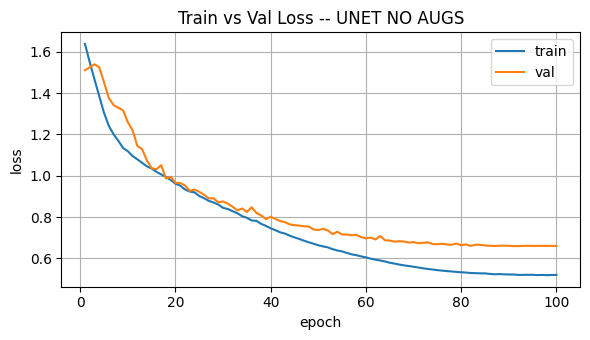

In [16]:
#UNET  W/ AUGS

import matplotlib.pyplot as plt

plt.figure(figsize=(6,3.5))
plt.plot(range(1, len(train_losses)+1), train_losses, label="train")
plt.plot(range(1, len(val_losses)+1),   val_losses,   label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.grid(True); plt.legend()
plt.title("Train vs Val Loss -- UNET NO AUGS")
plt.tight_layout()
plt.show()

In [17]:
# load best
model_core.load_state_dict(torch.load(SAVE_DIR / "best_unet_wo_aug_stare1.pth", map_location=DEVICE))
model_for_eval = model_core.eval()

# run your evaluation utility
print("STARE using GT2 wo augs - base unet")
evaluate_and_print(model_for_eval, test_dataloader=test_loader, device=DEVICE, threshold=0.5, compute_auc=True)

STARE using GT2 wo augs - base unet
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.7139
Specificity    : 0.9864
Dice           : 0.7466
Accuracy       : 0.9684
IoU            : 0.5969
Precision      : 0.7927
FPR            : 0.0136
FDR            : 0.2073
clDice         : 0.7975
Dice_thin      : 0.4623
Dice_thick     : 0.5866
ROC_AUC        : 0.9660
PR_AUC         : 0.8292
-- Micro (pooled over all pixels) --
Sensitivity    : 0.7143
Specificity    : 0.9864
F1/Dice        : 0.7498
Accuracy       : 0.9684
IoU            : 0.5997
Precision      : 0.7890
FPR            : 0.0136
FDR            : 0.2110
ROC_AUC        : 0.9654
PR_AUC         : 0.8237


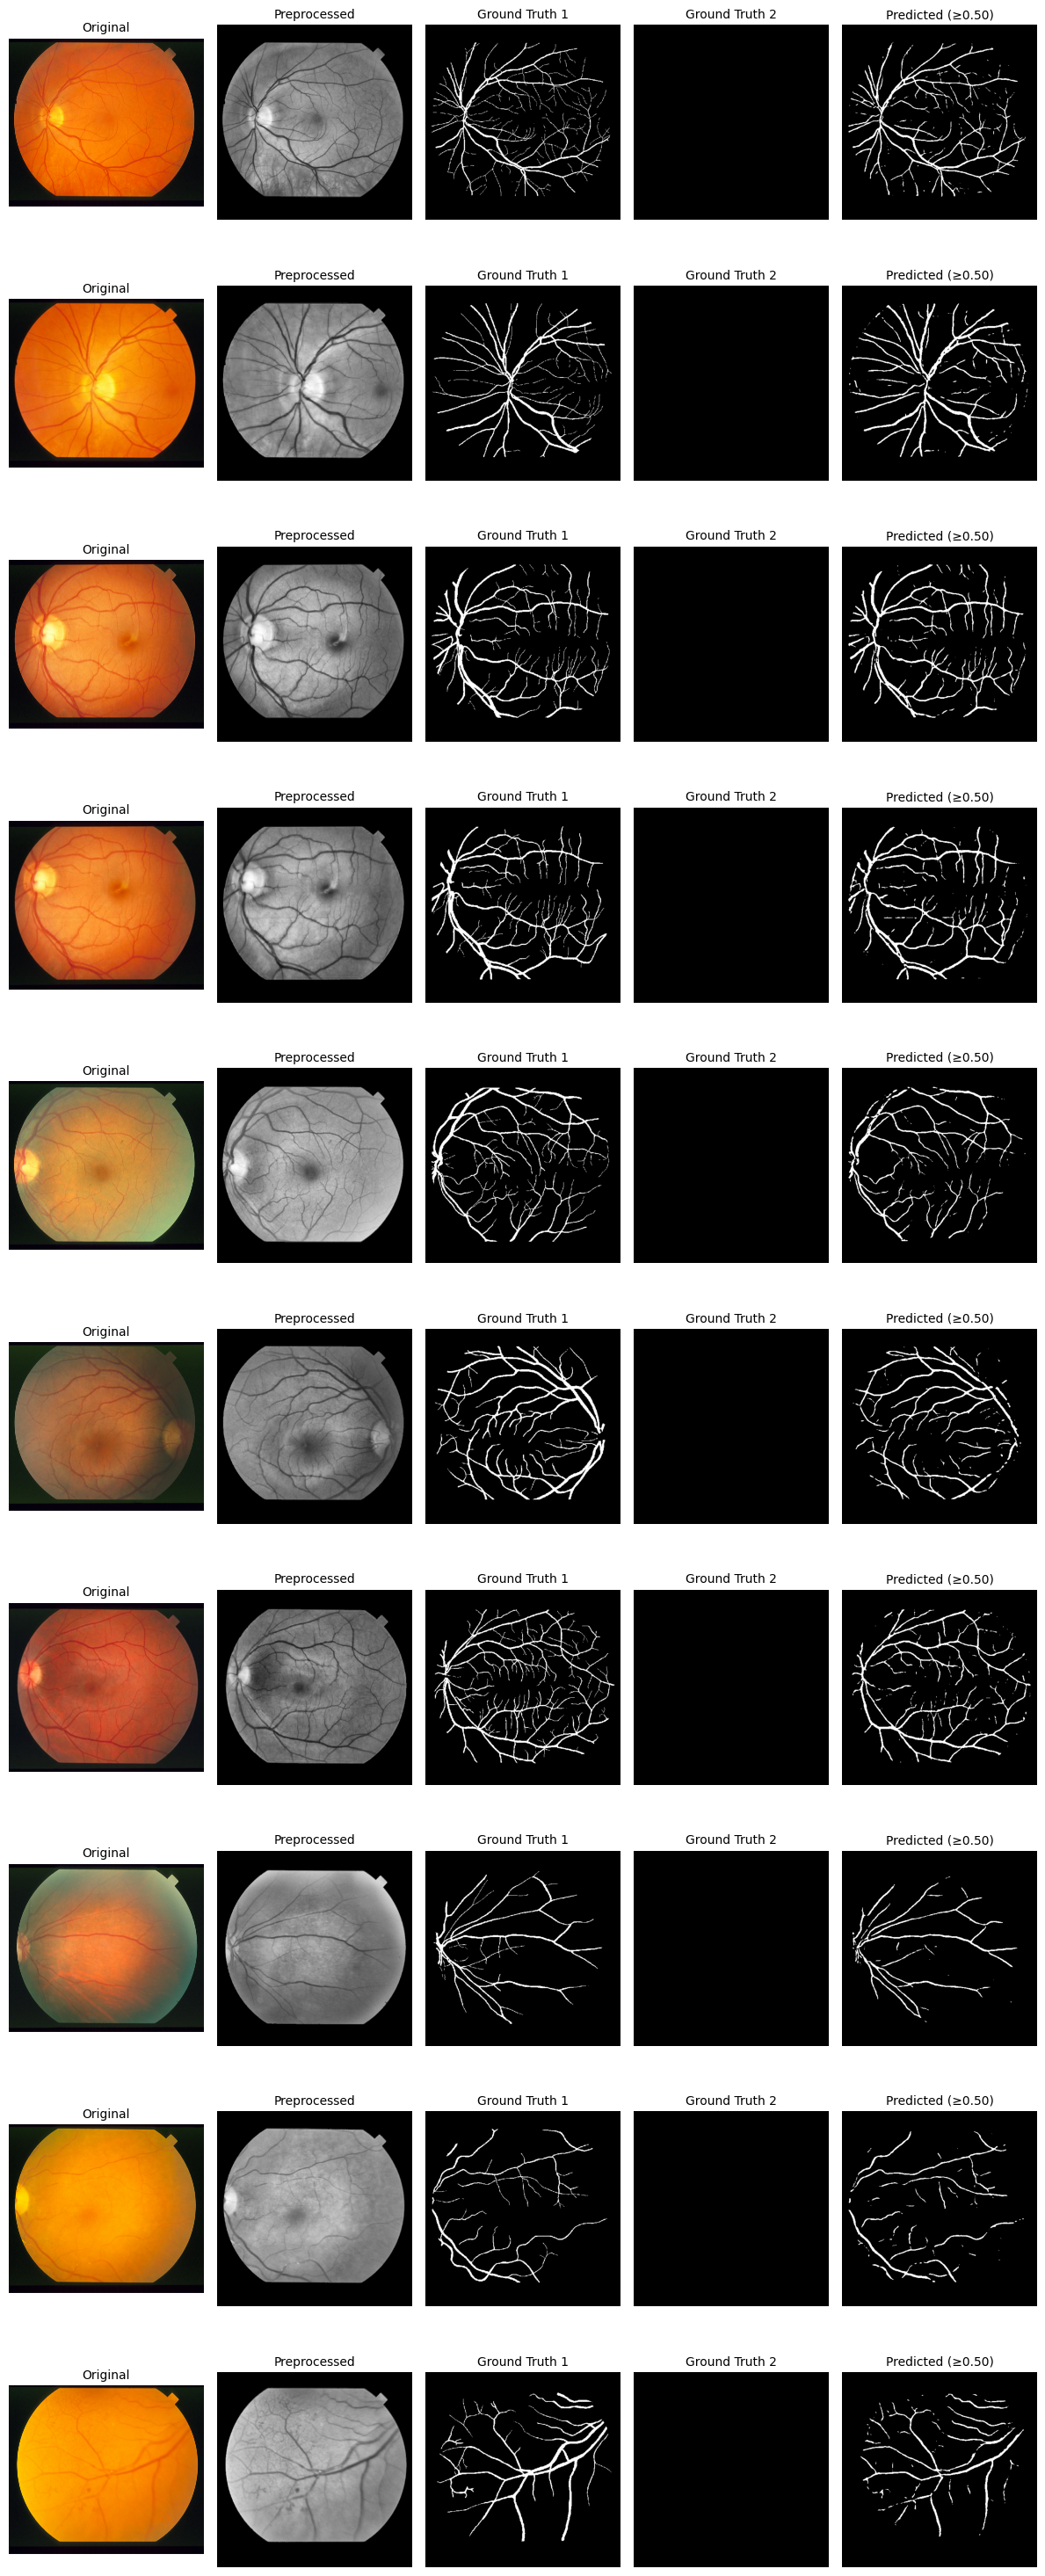

In [20]:
visualize_samples(
    model=model_for_eval,
    dataloader=test_loader,
    n_rows=10,
    device=DEVICE,
    threshold=0.5,
    clamp_pred_with_fov=True,
    figsize_per_row=(12, 3),
)

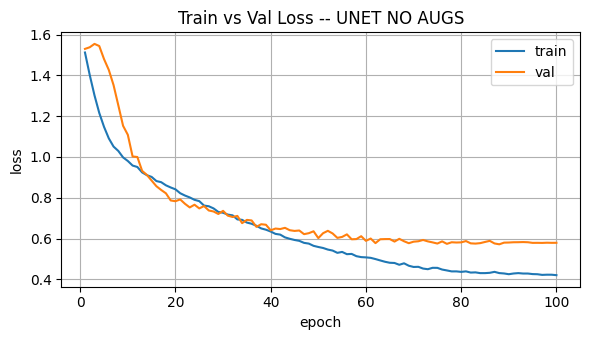

In [8]:
#UNET  W/ AUGS

import matplotlib.pyplot as plt

plt.figure(figsize=(6,3.5))
plt.plot(range(1, len(train_losses)+1), train_losses, label="train")
plt.plot(range(1, len(val_losses)+1),   val_losses,   label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.grid(True); plt.legend()
plt.title("Train vs Val Loss -- UNET NO AUGS")
plt.tight_layout()
plt.show()

In [ ]:
# load best
model_core.load_state_dict(torch.load(SAVE_DIR / "best_unet_wo_aug_stare2.pth", map_location=DEVICE))
model_for_eval = model_core.eval()

# run your evaluation utility
print("STARE using GT2 wo augs - base unet")
evaluate_and_print(model_for_eval, test_dataloader=test_loader, device=DEVICE, threshold=0.5, compute_auc=True)

STARE using GT2 wo augs - base unet
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.6422
Specificity    : 0.9859
Dice           : 0.7220
Accuracy       : 0.9527
IoU            : 0.5685
Precision      : 0.8435
FPR            : 0.0141
FDR            : 0.1565
clDice         : 0.7121
Dice_thin      : 0.3855
Dice_thick     : 0.5980
ROC_AUC        : 0.9452
PR_AUC         : 0.8121
-- Micro (pooled over all pixels) --
Sensitivity    : 0.6481
Specificity    : 0.9860
F1/Dice        : 0.7298
Accuracy       : 0.9527
IoU            : 0.5745
Precision      : 0.8350
FPR            : 0.0140
FDR            : 0.1650
ROC_AUC        : 0.9444
PR_AUC         : 0.8087


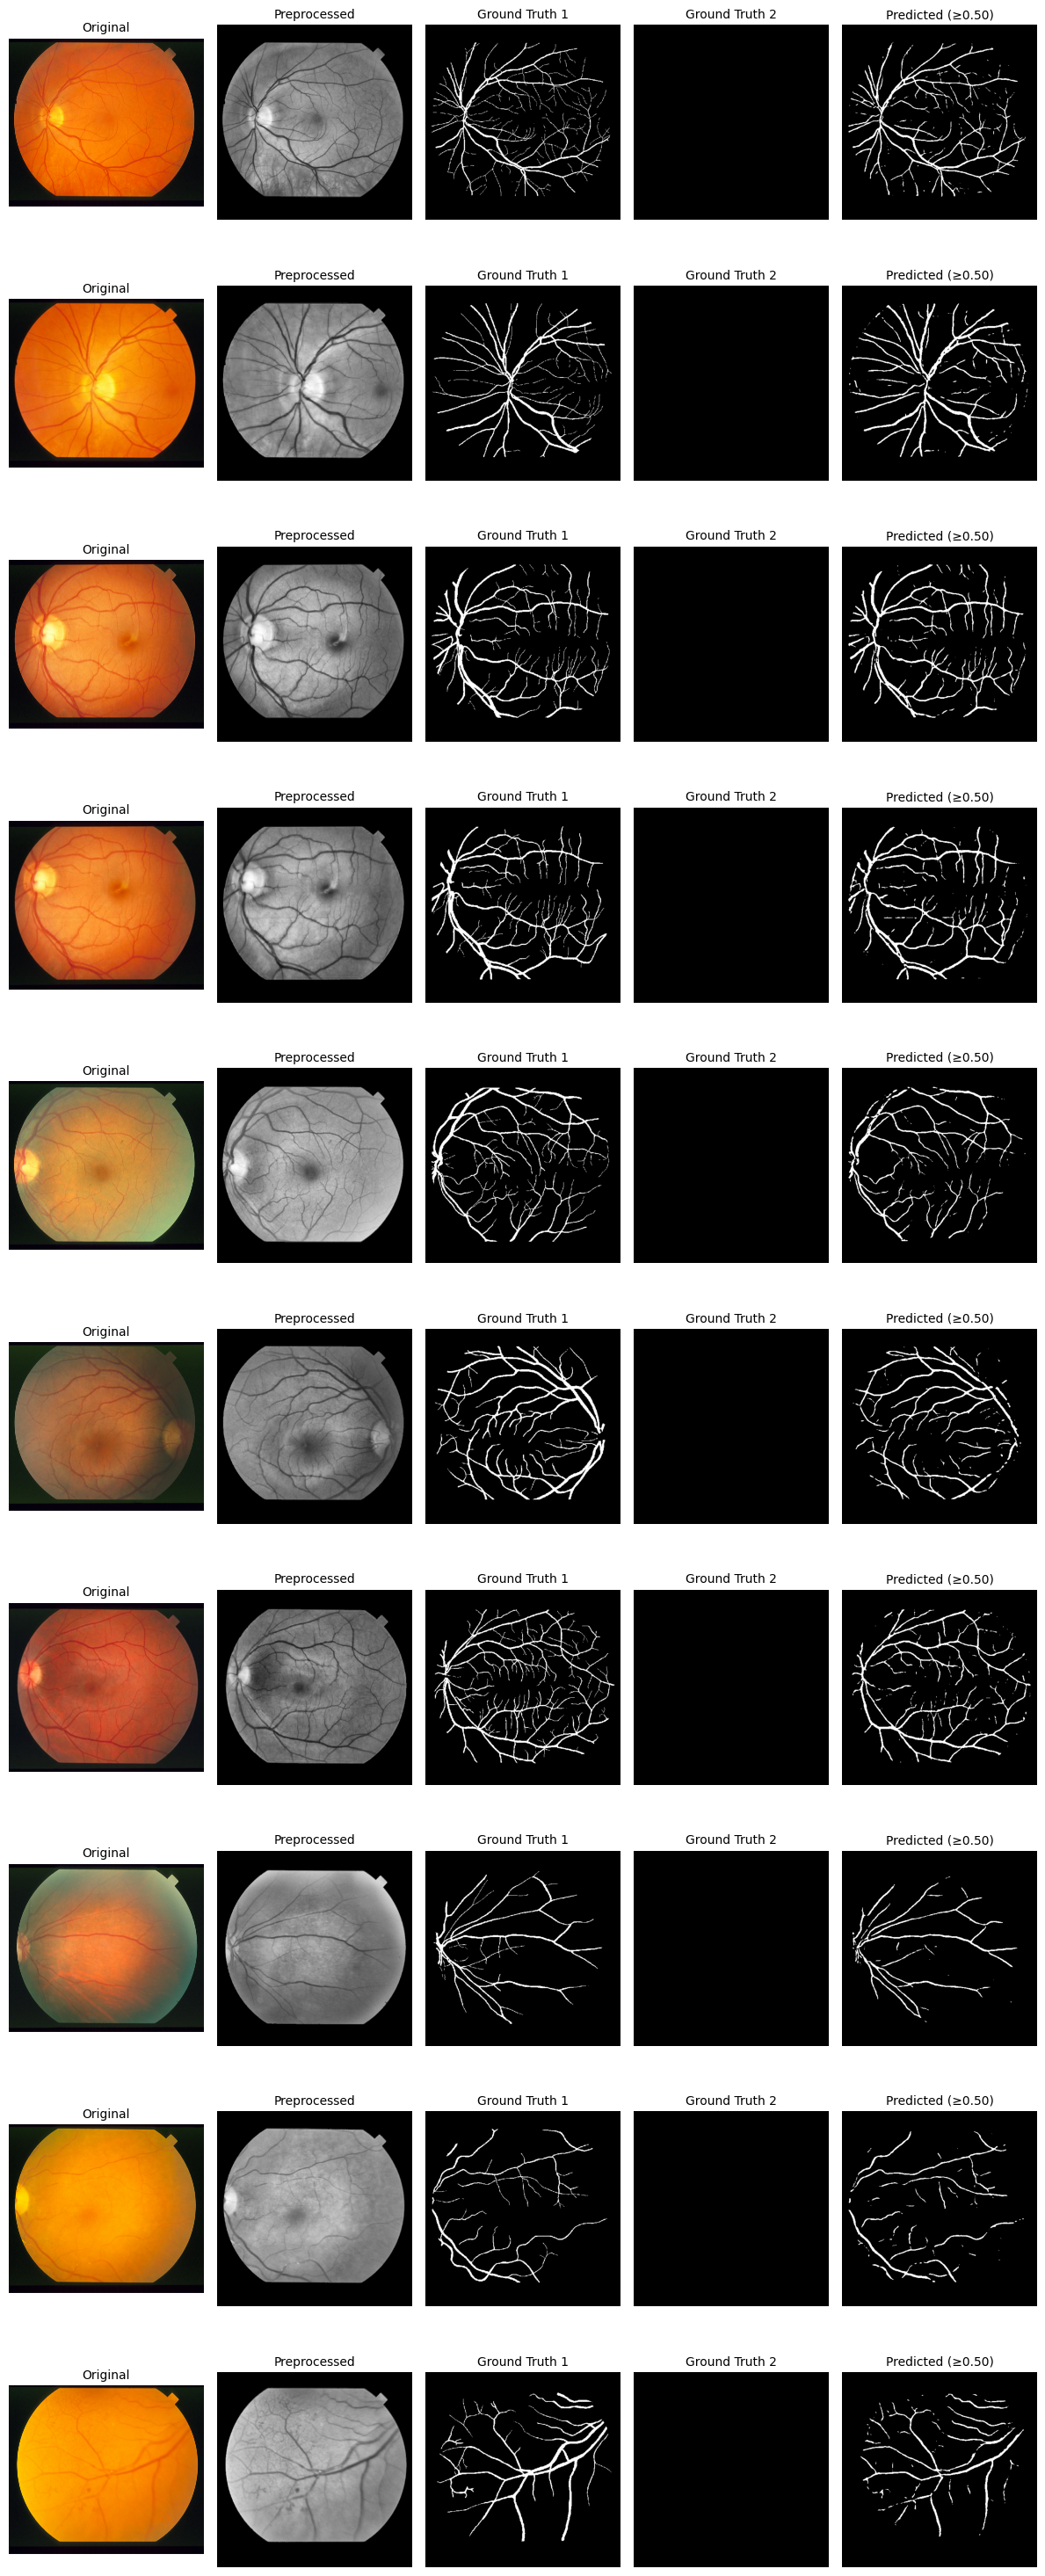

In [18]:
visualize_samples(
    model=model_for_eval,
    dataloader=test_loader,
    n_rows=10,
    device=DEVICE,
    threshold=0.5,
    clamp_pred_with_fov=True,
    figsize_per_row=(12, 3),
)